In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.DataFrame(pd.read_csv("insurance.csv"))

In [3]:
df["category"]=pd.qcut(df["charges"],q=3,labels=["Cheap","Moderate","Expensive"])

In [4]:
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

In [6]:
for train_idx, test_idx in split.split(df,df["category"]):
    stratasplit_train=df.loc[train_idx]
    stratasplit_test=df.loc[test_idx]

<Axes: >

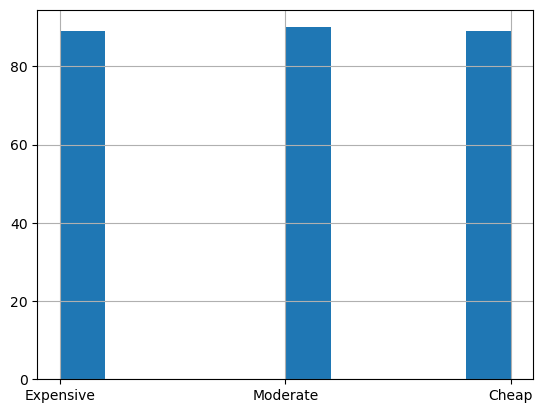

In [13]:
stratasplit_test["category"].hist()

In [19]:
stratasplit_test.drop(columns=["category"],inplace=True)

In [37]:
stratasplit_test.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
422,40,0.337429,1,2.120513,0,1,0,1,1,0,0,0
430,19,0.390310,0,0.803891,0,1,1,0,0,0,0,1
328,64,0.504207,1,2.842963,1,0,0,1,0,0,0,1
267,59,0.275599,3,0.106913,1,0,1,0,1,0,0,0
556,46,0.445631,1,-0.406530,0,1,1,0,1,0,0,0


In [23]:
stratasplit_train=pd.get_dummies(stratasplit_train,columns=["sex","smoker","region"],dtype=int)

In [26]:
stratasplit_test=pd.get_dummies(stratasplit_test,columns=["sex","smoker","region"],dtype=int)

In [29]:
scaler=StandardScaler()

In [31]:
stratasplit_train["charges"]=scaler.fit_transform(stratasplit_train[["charges"]])
stratasplit_test["charges"]=scaler.transform(stratasplit_test[["charges"]])

In [34]:
scaler2=StandardScaler()

In [35]:
stratasplit_train["bmi"]=scaler2.fit_transform(stratasplit_train[["bmi"]])
stratasplit_test["bmi"]=scaler2.transform(stratasplit_test[["bmi"]])

In [39]:
X_train,X_test=stratasplit_train.align(stratasplit_test,join="left",axis=1,fill_value=0)

In [40]:
X_train.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
489,53,0.074653,1,-0.231932,0,1,1,0,0,1,0,0
33,63,-0.389071,0,0.039570,0,1,1,0,0,1,0,0
71,31,-0.358156,5,-0.532521,0,1,1,0,1,0,0,0
747,19,-1.455634,0,-0.957009,0,1,1,0,0,1,0,0
720,51,1.620397,0,-0.280050,1,0,1,0,1,0,0,0


In [41]:
X_test.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
422,40,0.337429,1,2.120513,0,1,0,1,1,0,0,0
430,19,0.390310,0,0.803891,0,1,1,0,0,0,0,1
328,64,0.504207,1,2.842963,1,0,0,1,0,0,0,1
267,59,0.275599,3,0.106913,1,0,1,0,1,0,0,0
556,46,0.445631,1,-0.406530,0,1,1,0,1,0,0,0


In [47]:
x_train=X_train.drop(columns=["charges"]).copy()
y_train=X_train["charges"]

In [48]:
y_train.head()

489   -0.231932
33     0.039570
71    -0.532521
747   -0.957009
720   -0.280050
Name: charges, dtype: float64

In [49]:
x_test=X_test.drop(columns=["charges"]).copy()
y_test=X_test["charges"]

In [51]:
y_test.head()

422    2.120513
430    0.803891
328    2.842963
267    0.106913
556   -0.406530
Name: charges, dtype: float64